# Summer School - Modeling Water Fluxes In The Soil-Plant System

## Coupled Soil and Root Hydraulics, including perirhizal resistance to water flow



In this section we follow the approach of Schroeder et al. (2008) which use the steady rate approximation of the Richards equation in an axial-symmetric geometry.

In [1]:
import timeit
from functools import partial

import matplotlib.pyplot as plt
import numpy as np

import functional.van_genuchten as vg
import plantbox as pb
import visualisation.vtk_plot as vp
from functional.Perirhizal import PerirhizalPython  #as Perirhizal
from functional.PlantHydraulicModel import HydraulicModel_Doussan, HydraulicModel_Meunier
from functional.PlantHydraulicParameters import PlantHydraulicParameters
from richards import RichardsWrapper  # Python part
from rosi_richards import RichardsSP  # C++ part (Dumux binding)

sourcedir = "/home/jhack/phd/CPlantBox/"

In [2]:
def sinusoidal(t: float) -> float: # to plot daily variation in transpiration
    """ 
    Sinusoidal function (used for transpiration) (integral over one day is 1).
    
    Args:
        t (float): Time [days].
    
    Returns:
        float: Sinusoidal value at time t.
    """
    return np.sin(2. * np.pi * np.array(t) - 0.5 * np.pi) + 1.

def soil_picker(x: float, y: float, z: float, soil_model) -> int:
    """
    Maps a 3D coordinate (x, y, z) to the corresponding soil grid cell index.

    This function wraps the Richards solver's `pick()` method, which returns
    the index of the grid cell containing the given coordinates. It is used
    to couple plant root segments to the soil model in CPlantBox simulations.

    Args:
        x (float): X-coordinate [cm].
        y (float): Y-coordinate [cm].
        z (float): Z-coordinate [cm].
        soil_model: The soil model object (e.g. a RichardsWrapper instance).

    Returns:
        int: The index of the soil grid cell containing the point (x, y, z).
    """
    return soil_model.pick([x, y, z])

""" Parameters """  

min_b = [-4., -4., -25.] # [-35., -10., -50.] 
max_b = [4., 4., 0.] # [35., 10., 0.]  
cell_number = [8, 8, 25]  # [17, 5, 50]
    
path = sourcedir + "modelparameter/structural/rootsystem/"
name = "Zeamays_synMRI_modified"  #"Anagallis_femina_Leitner_2010"  # Zea_mays_1_Leitner_2010, Zeamays_synMRI.xml  <<<<-------
trans = 6.4 # 250  # cm3 /day (sinusoidal) = mL/day

    
wilting_point = -15000  # cm
rs_age = 21  # root system initial age [day]

loam = [0.078, 0.43, 0.036, 1.56, 24.96]  # hydrous loam
initial = -400  # cm

sim_time = 2 # 3.5  # [day]
dt = 360. / (24 * 3600)  # [days]  


In [3]:
""" Initialize macroscopic soil model """
s = RichardsWrapper(RichardsSP())  
s.initialize()
s.createGrid(min_b, max_b, cell_number, periodic = True)  # [cm]
s.setHomogeneousIC(initial, True)  # [cm] total potential
s.setTopBC("noFlux")
s.setBotBC("noFlux")
s.setVGParameters([loam])
s.setParameter("Soil.SourceSlope", "1000")  
s.initializeProblem()
s.setCriticalPressure(wilting_point)  

""" Initialize xylem model """
plant = pb.MappedPlant()  
plant.readParameters(path + name + ".xml")
sdf = pb.SDF_PlantBox(np.inf, np.inf, max_b[2] - min_b[2] - 0.1) # creates bounding box, here its periodic
plant.setGeometry(sdf) 

""" root hydraulic properties """
params = PlantHydraulicParameters() 
params.read_parameters(sourcedir + "modelparameter/functional/plant_hydraulics/couvreur2012")
# params.plot_conductivities(True)
hm = HydraulicModel_Doussan(plant, params)
hm.wilting_point = wilting_point  

""" Coupling (map indices) """
picker = partial(soil_picker, soil_model=s)  
plant.setSoilGrid(picker)
plant.setRectangularGrid(pb.Vector3d(min_b), pb.Vector3d(max_b), pb.Vector3d(cell_number), False, False)  
plant.initialize(True)
plant.simulate(rs_age, True)
hm.test()  

""" Perirhizal initialization """
peri = PerirhizalPython(hm.ms) 
# peri.open_lookup("results/hydrus_loam")  # faster with lookup table
peri.set_soil(vg.Parameters(loam)) # slower without lookup table

outer_r = peri.get_outer_radii("length") # outer radius of each rhizosphere cylinder [cm]
inner_r = peri.ms.radii # root radius of each root segment [cm]
rho_ = np.divide(outer_r, np.array(inner_r)) # ratio of outer to inner radius --> determines thickness of rhizosphere cylinder

Computed bounding box tree with 3199 nodes for 1600 grid entities in 0.000609175 seconds.
Computed bounding box tree with 3199 nodes for 1600 grid entities in 0.000697615 seconds.
MappedPlant::initializeLB 
Seed::initialize: RootSystem 
Seed::initialize: Shoot borne definition is DEPRICATED, shoot borne roots will be handeled like basal roots 
Organism::simulate: from 0 to 21 days
nodes moved 0
new nodes added 9290
segments added 9290
Number of segments 9291, including 9290 new 
PlantHydraulicModel.test():
9292 nodes:
Node 0 [ 0.1  0.  -3. ]
Node 1 [ 0.  0. -3.]
Node 2 [ 0.00445555  0.0391149  -3.49844776]
Node 3 [ 0.07686645  0.01432406 -3.99255512]
Node 4 [ 0.19069267  0.07267747 -4.34680949]
9291 segments:
Segment 0 [0 1] subType 0
Segment 1 [1 2] subType 1
Segment 2 [2 3] subType 1
Segment 3 [3 4] subType 1
Segment 4 [4 5] subType 2
Collar segment index 0
Collar segment [0 1]
0 segments with length < 1.e-5 cm
6 different root types from 0 to 5
ages from 0 to 21
segments 9291 9291



In [4]:
""" Numerical solution """
start_time = timeit.default_timer()
x_, y_, z_ = [], [], [] # time, transpiration, soil water content

hs = s.getSolutionHead_()  # [cm] matric potential aka soil solution head in each cell
hs_ = hm.ms.getHs(hs)  # [cm] matric potential per segment --> mapping
hsr = hs_.copy()  # initial values for fix point iteration 

N = round(sim_time / dt)
t = 0.

for i in range(0, N): 

    hx = hm.solve(rs_age + t, -trans * sinusoidal(t), hsr, cells = False) # compute xylem potential, given transpiration and soil-root interface potential
    hx_old = hx.copy()

    kr_ = hm.params.getKr(rs_age + t) # root radial conductivity per segment [cm3/day/cmH2O/cm]
    inner_kr_ = np.multiply(inner_r, kr_) # scaled by root radius --> effective radial conductivity of the rhizosphere cylinder

    err = 1.e6 
    c = 0
    while err > 100. and c < 100:  

        """ interpolation """
        hsr = peri.soil_root_interface_potentials(hx[1:], hs_, inner_kr_, rho_) # radial potentials in perirhizal cylinders

        """ xylem matric potential """
        hx = hm.solve_again(rs_age + t, -trans * sinusoidal(t), hsr, cells = False)  
        err = np.linalg.norm(hx - hx_old) # norm of change in xylem potential 
        hx_old = hx.copy()

        c += 1  

    water = s.getWaterVolume()  
    fluxes = hm.radial_fluxes(rs_age + t, hx, hsr, cells = False) # [cm3/day] soil to root per segment
    s.setSource(hm.sumSegFluxes(fluxes)) # set root uptake as source term in soil model
    s.solve(dt)
    soil_water = (s.getWaterVolume() - water) / dt # change in water per timestep

    hs = s.getSolutionHead()  # per cell 
    hs_ = hm.ms.getHs(hs)  # per segment

    x_.append(t) 
    y_.append(hm.get_transpiration(rs_age + t, hx.copy(), hsr.copy()))  # [cm3/day]
    z_.append(soil_water)  # [cm3/day] 

    if i % 1 == 0:
        n = round(float(i) / float(N) * 100.) 
        bar = '*' * n + ' ' * (100 - n)
        print(
            f"[{bar}] {c:g} iterations | "
            f"Soil hs [{np.min(hs):.1f}, {np.max(hs):.1f}] cm | "
            f"Interface hs: [{np.min(hsr):.1f}, {np.max(hsr):.1f}] cm | "
            f"Root hx: [{np.min(hx):.1f}, {np.max(hx):.1f}] cm | "
            f"Time: {s.simTime:.3f} days"
            )

#    if i % 10 == 0:  
#        vp.write_soil("results/example73_{:06d}".format(i // 10), s, min_b, max_b, cell_number)
#        vp.write_plant("results/example73_{:06d}".format(i // 10), hm.ms.plant())  

    t += dt

print (f"Coupled benchmark solved in {timeit.default_timer() - start_time} s")  

/home/jhack/phd/CPlantBox/src/functional/Perirhizal.py:86: RuntimeWarning: invalid value encountered in scalar divide
  k_soilfun = lambda hsoil, hint: (vg.fast_mfp[sp](hsoil) - vg.fast_mfp[sp](hint)) / (hsoil - hint)  # Vanderborgth et al. 2023, Eqn [7]


 -- Using the default temperature of 293.15 in the entire domain. Overload temperatureAtPos() in your spatial params class to define a custom temperature field.Or provide the preferred domain temperature via the SpatialParams.Temperature parameter.
[                                                                                                    ] 1 iterations | Soil hs [-412.0, -388.0] cm | Interface hs: [-412.0, -388.0] cm | Root hx: [-412.5, -387.7] cm | Time: 0.004 days
[                                                                                                    ] 1 iterations | Soil hs [-412.0, -388.0] cm | Interface hs: [-412.0, -388.0] cm | Root hx: [-412.6, -387.7] cm | Time: 0.008 days
[                                                                                                    ] 1 iterations | Soil hs [-412.0, -388.0] cm | Interface hs: [-412.0, -388.0] cm | Root hx: [-412.8, -387.7] cm | Time: 0.013 days
[*                                                     

KeyboardInterrupt: 

2025-10-13 13:40:07.087 (3951.301s) [    752487CC6080]       vtkXMLWriter.cxx:633    ERR| vtkXMLPolyDataWriter (0x121727f0): Error opening output file "results/Zeamays_synMRI_modified.vtp"
2025-10-13 13:40:07.087 (3951.301s) [    752487CC6080]       vtkXMLWriter.cxx:635    ERR| vtkXMLPolyDataWriter (0x121727f0): Error code "No such file or directory"
2025-10-13 13:40:07.088 (3951.302s) [    752487CC6080]       vtkExecutive.cxx:729    ERR| vtkCompositeDataPipeline (0x1ae74070): Algorithm vtkXMLPolyDataWriter (0x121727f0) returned failure for request: vtkInformation (0x10a791c0)
  Debug: Off
  Modified Time: 249256
  Reference Count: 1
  Registered Events: (none)
  Request: REQUEST_DATA
  FROM_OUTPUT_PORT: -1
  ALGORITHM_AFTER_FORWARD: 1
  FORWARD_DIRECTION: 0


2025-10-13 13:40:07.091 (3951.306s) [    752487CC6080]       vtkXMLWriter.cxx:633    ERR| vtkXMLImageDataWriter (0x1aff7b00): Error opening output file "results/Zeamays_synMRI_modified.vtu"
2025-10-13 13:40:07.091 (3951.306s) [  

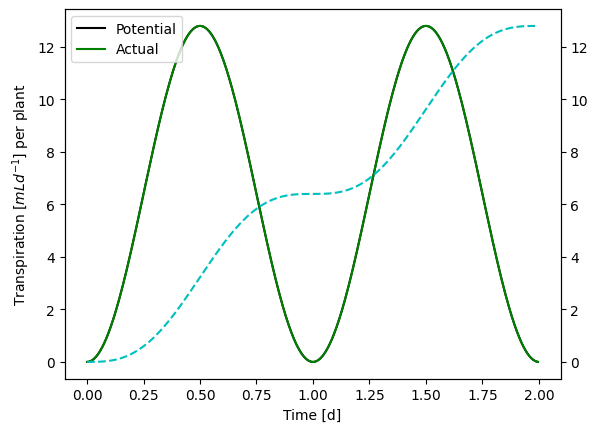

In [ ]:
""" VTK visualisation """ 
vp.plot_roots_and_soil(hm.ms.mappedSegments(), "pressure head", hx, s, 
       True, np.array(min_b), np.array(max_b), cell_number, name, interactiveImage = True)

""" Transpiration over time """
fig, ax1 = plt.subplots()
ax1.plot(x_, trans * sinusoidal(x_), 'k')  # potential transpiration
ax1.plot(x_, -np.array(y_), 'g')  # actual transpiration (neumann); negative bc water leaves soil
ax2 = ax1.twinx()
ax2.plot(x_, np.cumsum(-np.array(y_) * dt), 'c--')  # cumulative transpiration (neumann)
ax1.set_xlabel("Time [d]")
ax1.set_ylabel("Transpiration $[mL d^{-1}]$ per plant")
ax1.legend(['Potential', 'Actual', 'Cumulative'], loc = 'upper left')
# np.save("results/" + name + "_fp", np.vstack((x_, -np.array(y_), np.array(z_))))  
plt.show()

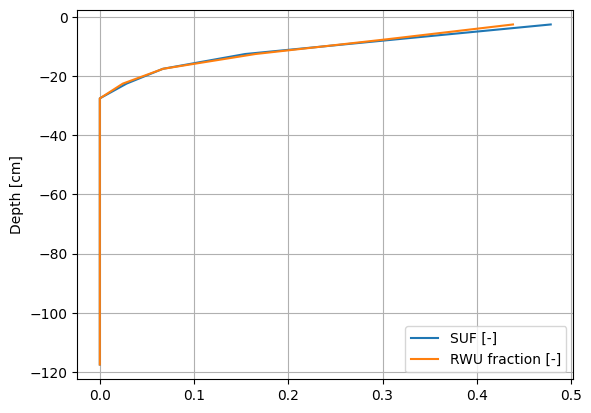

In [ ]:
def get_1d_from_3d(hm: HydraulicModel_Meunier | HydraulicModel_Doussan, data: np.ndarray, name: str, z_min: int) -> tuple[np.ndarray, np.ndarray]:
    """Convert 3D SUF (Standard Uptake Fraction) data to 1D depth profile for given hydraulic model and SUF values at each segment.
    
    Args:
        hm: Hydraulic model instance (either Meunier or Doussan); contains the mapped segments.
        data: Array of SUF values at each segment in the 3D root structure.

    Returns:
        suf_array: 1D array of SUF values averaged over horizontal layers.
        depth_array: Corresponding depth midpoints for the SUF values [cm].
        name: Name identifier for the data (used in SegmentAnalyser).
        z_min: Minimum depth to consider for binning [cm].

    Notes:
        The function bins the root system along the z-axis (soil depth) with 5 cm layers (bin size hardcoded in function) 
        and computes the total SUF in each layer.
    """
    ana = pb.SegmentAnalyser(hm.ms)
    ana.addData(name, data)  # data at each segment in the 3d space; adds a field (name) containing per segment values
    
    bin_size = 5  # soil layer thickness is defined, for plotting purposes
    z_max = 0
    n_bins = int((z_max - z_min) / bin_size)
    suf_dist = ana.distribution(name, z_max, z_min, n_bins, True) # total data per depth layer; args: data field, bounds, layers, normalize per layer
    
    depths = np.linspace(z_max - bin_size / 2, z_min + bin_size / 2, n_bins) # depth midpoints of layers
    suf_array = np.array(suf_dist) # array of data values
    depth_array = np.array(depths) # array of depths
    return suf_array, depth_array
    
suf_array, depth_array = get_1d_from_3d(hm, hm.get_suf(rs_age+t), "SUF", -120.)
hx = hm.solve(rs_age, -trans*sinusoidal(0.5), hs, cells=True)
radial_fluxes = hm.radial_fluxes( rs_age+t, hx, hs, cells = True)
rwu_array, depth_array = get_1d_from_3d(hm, radial_fluxes, "RWU", -120.) # [cm3/day] root water uptake
rwu_array /= sum(rwu_array) # normalize to 1


plt.plot(suf_array, depth_array, label = "SUF [-]")
plt.plot(rwu_array, depth_array, label = "RWU fraction [-]")
plt.ylabel("Depth [cm]")
plt.grid(True)
plt.ylim(depth_array.min() - 5, depth_array.max() + 5)  # optional padding
plt.legend()
plt.show()  

With the following code snipet, a 4D look-up table is created that speeds up the computation, since all matric potentials at the soil root interface $h_{sr}$ are tabularized for: xylem matric potentials $h_x$ [cm], bulk soil matric potentials, $h_{bs}$ [cm], root radius times hydraulic conductivity [cm/day] , and the geometry factor $\rho$ [1] (outer radius / inner radius). The lookup table takes around 500MB and between several minutes to several hours to compute, depending on the number of cores used.  

In [ ]:
peri = PerirhizalPython() # creates new perirhizal model instance
hydrous_loam = [0.078, 0.43, 0.036, 1.56, 24.96] # specify van Genuchten parameters
filename = "hydrous_loam" # assign a file name for the lookup table
sp = vg.Parameters(hydrous_loam) # wrap parameters in van Genuchten parameter class
vg.create_mfp_lookup(sp) 
peri.create_lookup_mpi("results/" + filename, sp) # prep lookup table for perirhizal calculations
# --> allows for fast interpolation of matric potential in rhizosphere cylinder for given flux and soil matric potential 